# Hydraulic Control 
## PHYS 426 Fluid Mechanics
### By: Shuyang W. & Paul R.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import sympy as sp
import ipywidgets as widgets
from IPython.display import Video, display
import os

# Abstract

This experiment delves into the behaviour of fluids when interacting with some obsticle or wier. Two demostrations were performed with this goal in mind (1) Observing downstream behaviour over varying types of weirs and flow rates, and (2) creation of a hydraulic jump using a variety of weir types. The downstream behaviours were later compared to the theoretical flow rates depending on initial conditions of the system. The hydraulic jump criteria was also shown along with the relation to energies of the system. 

# 1 Introduction

## 1.1 Derivation of flow rates over varying weir types

### Like most fluid mechanics we start from Bernoulli's principal

$\frac{P_u}{\rho} + \frac{U_u^2}{2} + g z_{u} = \frac{P_w}{\rho} + \frac{U_w^2}{2} + g z_{w} $   

Because the tank is open to air we can assume that both pressures are atmospheric which causes the terms to cancel. 

$ \frac{U_u^2}{2} + g z_{u} =  \frac{U_w^2}{2} + g z_{w} $  

Another easy assumption made is that the upstream approch velocity is negligible due to the relative areas of the weir and upstream resevoir

$ g z_{u} =  \frac{U_w^2}{2} + g z_{w} $  

Setting $ z_{u} = H $ and $z_{w} = z$ . Where $H$ is the water level and $z$ is some stream line height above the start of the weir.

$ g (H-z) = \frac{U_w^2}{2}$

Further simplifying 

$ U_w = \sqrt{2g(H-z)}$



### Now we can start to construct the flow rate given the water speed at the crest

$ dQ = U(z) \cdot dA = U(z) b(z) dz$

Where $b(z)$ is the width of the strip over $dz$. Integrating with respect to z yeilds 

$ Q = \int_{0}^{H} U(z) b(z) dz  = \int_{0}^{H} \sqrt{2g(H-z)} b(z) dz$

The only remaining unknown is b(z), which varies depending on the geometry of the weir. 

### Solving for the width b(z)

For the rectangular weir this is fairly trivial as the width is constant along the height of the weir. 

$b(z) = b$

resulting in a flow rate of:

$ Q = b \int_{0}^{H} \sqrt{2g(H-z)} dz$

The notched weir is significantly less trivial. first we only consider one half $a(z)$ as we understand right triangles pretty well. 

$b(z) = 2 a(z)$

$\frac{a(z)}{z} = \tan{\theta / 2}$

$b(z) = 2 z \tan{\theta / 2} $

And finally putting this into our integral yeilds, 

$ Q = 2 \int_{0}^{H} \sqrt{2g(H-z)} z \tan{\theta / 2} dz$



In [17]:
#Evaluating both integrals
z, H, g = sp.symbols('z H g', positive=True, real=True)
b = sp.symbols('b', positive=True, real=True)          # rectangular width
theta = sp.symbols('theta', positive=True, real=True)  # notch included angle

U = sp.sqrt(2*g*(H - z))

Q_rect = sp.integrate(U * b, (z, 0, H))
Q_rect = sp.simplify(Q_rect)

b_z = 2*z*sp.tan(theta/2)
Q_notch = sp.integrate(U * b_z, (z, 0, H))
Q_notch = sp.simplify(Q_notch)



In [18]:
Q_rect

2*sqrt(2)*H**(3/2)*b*sqrt(g)/3

In [19]:
Q_notch

8*sqrt(2)*H**(5/2)*sqrt(g)*tan(theta/2)/15

In [20]:
for name in ["z", "H", "g", "b", "theta", "U", "Q_rect", "Q_notch", "b_z"]:
    globals().pop(name, None)


Cleaning up the final result a bit leads to 

$Q_{rect} = \frac{2}{3} \sqrt{2g} b H^{3/2} $

$Q_{notch} = \frac{8}{15} \sqrt{2g} \tan{\frac{\theta}{2}} H^{5/2}$

While these values may not be completely acurate due to the idealized conditions, it will show the proportionality between $Q$ and $g^{\alpha} H^{\beta}$. There is generally some constant denoted $C_{d}$ that is used make the relations true.

To assess these relations we took some measurements on the flow rates of each weir.

While H was initally defined as the height from the bottom of the upstream reservoir, only the component past the height of the weir will contribute. This value is stored in the head variable below. 

In [21]:
#theoretical flow rates

def Q_rect_theo(H, b, g=9.81):
    return (2/3) * b * np.sqrt(2*g) * H**(3/2)

def Q_notch_theo(H, theta, g=9.81):
    return (8/15) * np.tan(theta/2) * np.sqrt(2*g) * H**(5/2)


## 1.2 Estimating the time required for outflow to start

#### Next we tried to estimate the time it would take to initally spill over each crest

In theory the time it would take can be split into two components. 

$t_{spill} = t_{fill} + t_{SurfacetTension}$

The time to fill the reservior can be estimated fairly trivially as the area is constant with height. 

$t_{fill} = \int_{h_0}^{h_c} \frac{A_0}{Q_0} dh$

$t_{fill} = \frac{(h_c - h_0)A_0}{Q_0}$

The tension effect time is fairly similar in form except we have to consider typical properties of water at room temperature. also for the future this time is denoted $t_{\sigma}$. 

$t_{\sigma} = \frac{A_0}{Q_0} \Delta h_{\sigma}$

$\Delta h_{\sigma}$ describes the height past the crest height needed to overcome surface tension.

$\Delta h_{\sigma} = \frac{\sigma}{\rho g} \frac{1}{r_{edge}}$

As both weir's have the same edge distance and water properties this can be treated as a constant.

## 1.3 Hydraulic Jump

Hydraulic jump is a phenomenon in fluid dynamics where a sudden change in the flow occurs. It is often representing the change from a high-velocity, low-depth flow (supercritical) to a low-velocity, high-depth flow (subcritical).

Consider an open channel flow with a bump in the channel, and the downstream flows into a large reservoir. The bump left stream is subcritical, and the bump right stream is supercritical at first, but then at some point, a hydraulic jump forms and the stream transforms to subcritical flow.

During the hydraulic jump, the flow energy changes, but the momentum flux is conserved. Using these, we can find the position of the hydraulic jump. We have flow energy:

$$
B = \frac{u^2}{2} + g(z_b + h) = \frac{1}{2} \left(\frac{Q}{h}\right)^2 + g(z_b + h)
$$

and the momentum flux:

$$
M = h u^2 + \frac{1}{2} g h^2 = \frac{Q^2}{h} + \frac{1}{2} g h^2
$$

# 2 Procedure

## 2.1 System

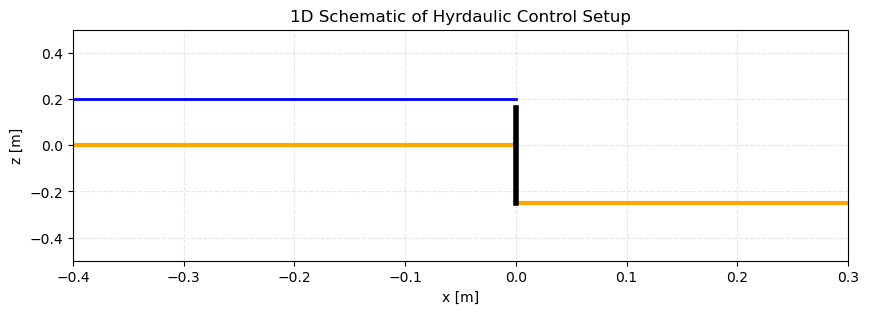

In [16]:

L_up = 0.4        # length of upstream reservoir [m]
H_up = 0.20       # upstream water depth above upstream bottom [m]
L_down = 0.3      # length of downstream tank


x_up = np.linspace(-L_up, 0, 100)
x_down = np.linspace(0, L_down, 100)

# plotting
fig, ax = plt.subplots(figsize=(10,3))

# upstream bottom
ax.plot(x_up, np.zeros_like(x_up), color='orange', lw=3, label="Upstream Bottom")
ax.plot(x_down, -0.25 * np.ones_like(x_down), color='orange', lw=3, label="Downstream Bottom")

# upstream free surface
ax.plot(x_up, H_up * np.ones_like(x_up), color='blue', lw=2)

# weir 
ax.plot([0, 0], [-0.25, H_up -0.04], color='black', lw=4)


ax.set_xlim(-L_up, L_down)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
ax.set_title("1D Schematic of Hyrdaulic Control Setup")
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()


Quick 1D schematic of measurement apparatus. Water flows into upstream reservoir before interacting with the weir shown at x=0. This water the falls into the lower downstream reservoir. Flow rate was measured at both points. 

## 2.2 Flow Rate Measurements

There were 3 methods used for measuring the flow rate of the system. 

(1) Water was input to a bucket of known volume directly from the output tube. The time to fill this bucket was taken and averaged at a variety of flow rates. A general flow rate curve was taken by interpolating along the three data points.

(2) Measure the height change of the upstream reservoir over a time interval. The area of the reservoir is known. (Initial filling to spill over weir). Also noted final water level height after reaching steady state for theoretical comparison.

(3) Measure the height change of the downstream reservoir over a time interval. The area of the reservoir is known. (steady state)

In [ ]:
#notch weir in steady state video
path = "IMG_5562.mov"  
display(Video(path, embed=False))


## 2.3 Generating Hydraulic Jumps


In [ ]:
#bunch of measurements from the hydraulic jump videos

volume = np.pi * (0.15)**2 * 0.16 
flow_time = 34.51 
Q_meas = volume / flow_time
print(f"Measured flow rate for both weirs: {Q_meas:.6f} m^3/s")

downstream_water_level = 0.02 #m
tank_width = 0.09 #m

Measured flow rate for both weirs: 0.000328 m^3/s


In [ ]:
#normal weir video
path = "IMG_5609.mov"  
display(Video(path, embed=False))
dist_to_jump_from_crest = 0.2 #m
upstream_water_level = 0.07 #m
weir_height = 0.05 #m

In [31]:
#side weir video
path = "IMG_5610.mov"  
display(Video(path, embed=False))
dist_to_jump_from_crest_side = 0.13 #m
upstream_water_level_side = 0.04 #m
weir_width = 0.03 #m

# 3 Results and Discussion

## 3.1 Flow Rates 

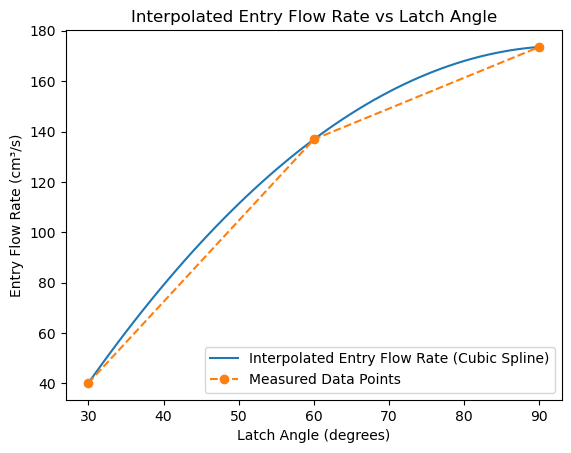

In [22]:
#Initial entry flow rate calculations

V0 = np.pi * (29.0/2)**2 * 14.0 * 1e-6 # m^3

t_in = np.array([53.27, 67.55, 229.99])
theta_in = np.array([90.0, 60.0, 30.0]) # latch degrees eg. 90 is fully open

t_in = t_in[::-1]
theta_in = theta_in[::-1]

q_in = V0 / t_in # m^3/s
spline = CubicSpline(theta_in, q_in)

theta = np.linspace(30, 90, 61)
q_interp = spline(theta)

plt.figure()
plt.plot(theta, q_interp * 1e6, '-', label='Interpolated Entry Flow Rate (Cubic Spline)')
plt.plot(theta_in, q_in * 1e6, 'o--', label='Measured Data Points')
plt.plot
plt.xlabel('Latch Angle (degrees)')
plt.ylabel('Entry Flow Rate (cm³/s)')
plt.title('Interpolated Entry Flow Rate vs Latch Angle')
plt.legend()
plt.show()

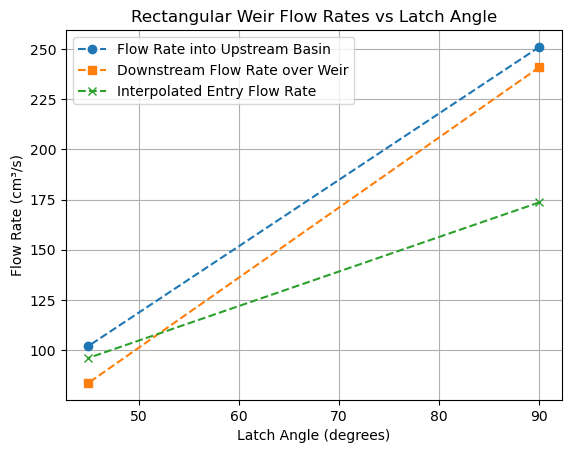

In [75]:
#rectangular weir
Ad1 = 0.64 * 0.32 #downstream basin area in m^2
Ad2 = 0.64 * 0.15 #2nd downstream basin area in m^2
Au = 0.68 * 0.24 #upstream basin area in m^2
b = 0.05 # weir width in m
weir_egde_length = 0.002 #mm
g=9.81

theta_meas = np.array([90, 45]) #latch angles for rectangular weir dictating flowrates, 90 is fully open

upstream_volume_change_meas =  Au * np.array([0.02, 0.015]) #change in volume upstream basin
downstream_volume_change_meas = np.array([Ad1 * 0.02, Ad1 * 0.02]) #change in volume downstream basin

t_fill_meas = np.array([13, 24]) #for upstream flowrate
t_steady_meas = np.array([17, 49]) #for downstream flowrate
t_spill_meas = np.array([19, 53]) #time to spill over weir


qu_rect = upstream_volume_change_meas / t_fill_meas
qd_rect = downstream_volume_change_meas / t_steady_meas

qu_interp = spline(theta_meas)
head_steady_rect = np.array([0.115, 0.105]) -0.1#steady state height at the weir

#plotting

plt.figure()
plt.plot(theta_meas, qu_rect*1e6, 'o--', label='Flow Rate into Upstream Basin')
plt.plot(theta_meas, qd_rect*1e6, 's--', label='Downstream Flow Rate over Weir')
plt.plot(theta_meas, qu_interp*1e6, 'x--', label='Interpolated Entry Flow Rate')
plt.xlabel('Latch Angle (degrees)')
plt.ylabel('Flow Rate (cm³/s)')
plt.title('Rectangular Weir Flow Rates vs Latch Angle')
plt.legend()
plt.grid()
plt.show()

The data for this was measured again at a different date, hence the discrepencies in slope between the measured flow rates and intpolated flow rates.

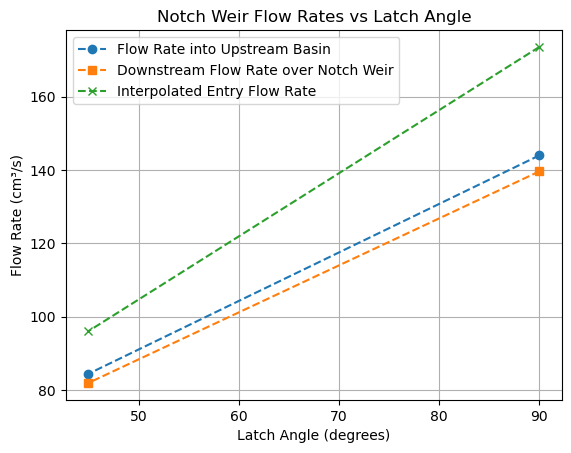

In [70]:
#notch weir 

notch_angle = np.pi/2 #90 degrees

Ad = 0.64 * 0.32 #downstream basin area in m^2
Au = 0.68 * 0.24 #upstream basin area in m^2

theta_meas_notch = np.array([90.0, 45.0]) #latch degree dictating flow rate, not notch angle

upstream_volume_change_meas_notch = Au * np.array([0.015, 0.015])
downstream_volume_change_meas_notch = Ad * np.array([0.015, 0.02])

t_fill_meas_notch = np.array([17, 29]) #for upstream flowrate
t_steady_meas_notch = np.array([22, 50]) #for downstream flowrate
t_spill_meas_notch = np.array([20, 34]) #time to spill over weir

head_steady_notch = np.array([0.122, 0.115]) -0.1#steady state height at the notch

qu_notch = upstream_volume_change_meas_notch / t_fill_meas_notch
qd_notch = downstream_volume_change_meas_notch / t_steady_meas_notch

qu_interp_notch = spline(theta_meas_notch)

#plotting
plt.figure()
plt.plot(theta_meas_notch, qu_notch * 1e6, 'o--', label='Flow Rate into Upstream Basin')
plt.plot(theta_meas_notch, qd_notch * 1e6, 's--', label='Downstream Flow Rate over Notch Weir')
plt.plot(theta_meas_notch, qu_interp_notch * 1e6, 'x--', label='Interpolated Entry Flow Rate')
plt.xlabel('Latch Angle (degrees)')
plt.ylabel('Flow Rate (cm³/s)')
plt.title('Notch Weir Flow Rates vs Latch Angle')
plt.legend()
plt.grid()
plt.show()


### 3.1.2 Comparing to derived flow rates

In [76]:
q_rect_theo = Q_rect_theo(head_steady_rect, b) 
q_notch_theo = Q_notch_theo(head_steady_notch, notch_angle)


print(f"Ratio between Theoretical and Measured Rectangular Weir Flow Rates: {q_rect_theo / qd_rect}")
print(f"Ration between Theoretical and Measured Notch Weir Flow Rates: {q_notch_theo / qd_notch}")

Ratio between Theoretical and Measured Rectangular Weir Flow Rates: [1.1257815  0.62448122]
Ration between Theoretical and Measured Notch Weir Flow Rates: [1.21452484 0.7946693 ]


Ideally the ratio everywhere would be one. However we are seeing some discrepancies between the theoretical derivation and the measured values. This is due to factors that are unconsidered in the theoretical formulation. For example the neglection of the upstream resevoir fluid velocity. The model also does not consider any turbulence that may occur within the upstream reservoir. Lastly the model ignores the effects of friction/viscosity which may create some more issues. 

Our measured results are fairly consistant as they are all within 0.25 except for the slow flow rate of the rectangular notch. This lagging behind could be due to the inprecise manor of controlling flow rate with the latch. The latch has no exact measurements so it probably that the flow rate was not exactly as expected. 

## 3.2 Spill Times

In [78]:

deltah = (0.072)/ (9.81*1000*weir_egde_length)
# print(f"tension head: {deltah} m")

t_spill_rect = (upstream_volume_change_meas + deltah * Au) / q_rect_theo
t_spill_notch = (upstream_volume_change_meas_notch + deltah * Au) / q_notch_theo

print(f"Theoretical Rectangular Weir Spill Times (s): {t_spill_rect}")
print(f"Theoretical Notch Weir Spill Times (s): {t_spill_notch}")

print(f"Measured Rectangular Weir Spill Times (s): {t_spill_meas}")
print(f"Measured Notch Weir Spill Times (s): {t_spill_meas_notch}")

print(f"Ratio of Theoretical to Measured Rectangular Weir Spill Times: {t_spill_rect / t_spill_meas}")
print(f"Ratio of Theoretical to Measured Notch Weir Spill Times: {t_spill_notch / t_spill_meas_notch}")


Theoretical Rectangular Weir Spill Times (s): [14.24125383 58.36800059]
Theoretical Notch Weir Spill Times (s): [17.96607211 46.8038623 ]
Measured Rectangular Weir Spill Times (s): [19 53]
Measured Notch Weir Spill Times (s): [20 34]
Ratio of Theoretical to Measured Rectangular Weir Spill Times: [0.74953968 1.10128303]
Ratio of Theoretical to Measured Notch Weir Spill Times: [0.89830361 1.37658419]


Again a small discrepancy between the measured values and expected time. The error on this measurement is likely due to the flow rate not being exactly consistent. The flow rate is also slightly altered by a cage that will slow down the flow. There was also some small leakage of water through the weir reducing the consistancy of the measurement. 

## 3.3 Hydraulic Jump Simulations

For the following simulations the up stream energy $B_{up}$ is fixed. The down stream energy $B_{down}$ is varying by controlling the downstream water level. For each $B_{down}$, we get a down stream momentum flux. For each value of $B$, we get the stream depth $h$ along the channel by solving the energy equation. That we get two sets of $h$ values, we can calculate the momentum flux for each set of $h$ values, and find the position where the two momentum fluxes are equal. That is the position of the hydraulic jump.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
%matplotlib ipympl

from sve_hybrid import run_modelFVM

0.18


Running model:   1%|          | 139/15000 [00:00<00:10, 1367.20it/s]

upstream subcritical
upstream subcritical


Running model: 100%|██████████| 15000/15000 [00:10<00:00, 1462.55it/s]


<xarray.Dataset> Size: 611kB
Dimensions:  (x: 250, time: 151)
Coordinates:
  * x        (x) float64 2kB 0.0 0.1 0.2 0.3 0.4 ... 24.5 24.6 24.7 24.8 24.9
  * time     (time) float64 1kB 0.0 1.0 2.0 3.0 4.0 ... 147.0 148.0 149.0 150.0
Data variables:
    A        (time, x) float64 302kB 0.13 0.13 0.13 0.13 ... 0.0 0.0 0.0 0.0
    Q        (time, x) float64 302kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    zb       (x) float64 2kB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0 0.0
    b        (x) float64 2kB 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0 1.0
    Qup      float64 8B 0.18
    Adown    float64 8B 0.33
Attributes:
    description:  Made with run_modelFVM(nTimes, saveT, dt, dx, zb, b, A, Q, ...

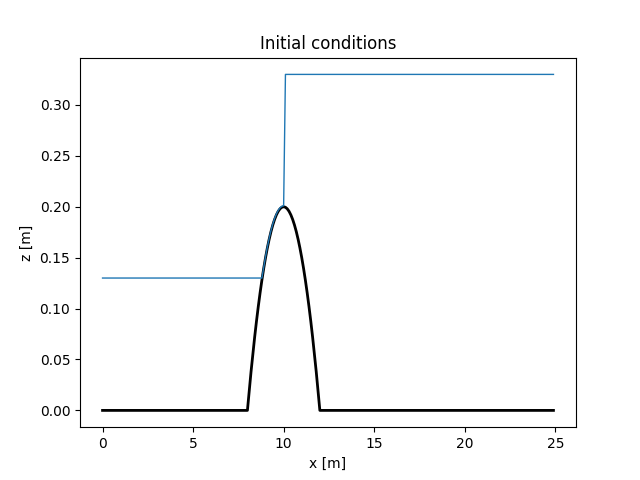

In [ ]:
# Calculate the hydraulic model

nTimes = 15_000
saveT = 100
dt = 0.01
time = np.arange(0, dt*nTimes+1, saveT*dt)

dx = 0.1   # m
nx = 250
x = np.arange(0, dx*nx, dx)
#x = x
# width:
b = np.ones(nx)  # width in m.

Manning = 0.0014 + 0*b # friction
Manning = 0.0 * Manning
# Manning[:30] = 0
drylim = 1e-10

# Bottom
zb = np.zeros(nx)
zb[(x>=8.0) & (x<=12)] = 0.2 - 0.05*(x[(x>=8.0) & (x<=12)]-10)**2
#zb = 0.2*np.exp(-((x-10)/1.6)**2)

# initial height
h = 0.13 - zb
h[x>10] = 0.33 - zb[x>10]
A = h * b
drylim=1e-3

# inital flow
Qup = 0.18
u0 = Qup / A[0]
print(Qup)

Q = np.zeros(nx) + 0* u0*A # Flow rate m^3/s
# Q = np.zeros(nx) + Qup # Flow rate m^3/s

Q[(A/b)<drylim] = 0.0
A[(A/b)<drylim] = drylim * b[(A/b)<drylim]


if True:
    saveA, saveQ = run_modelFVM(nTimes, saveT, dt, dx, zb, b, A, Q, Qup=Qup, Aup=None, kappa=0*3e-1/16, K4=10e-5, Manning=Manning, drylim=drylim, Adown=A[-1])
    #saveA, saveQ = run_modelFVM(nTimes, saveT, dt, dx, zb, b, A, Q, Qup=Qup, Aup=None,
    #                            kappa=.5e-1/16, Manning=0.0 * b, drylim=drylim, Adown=A[-1])

    # Save the model output to a netcdf file.
    ds = xr.Dataset(coords={'x':x, 'time':time})
    ds.attrs['description'] = 'Made with run_modelFVM(nTimes, saveT, dt, dx, zb, b, A, Q, Qup=Qup, Aup=None, kappa=0, A4=1e-4, Manning=0.0 * b, drylim=drylim, Adown=A[-1])'
    ds['x'].attrs['description'] = 'x [m]'
    ds['time'].attrs['description'] = 'time [s]'
    ds['A'] = (('time', 'x'), saveA)
    ds['A'].attrs['description'] =  'Cross-sectional area [m^2]'

    ds['Q'] = (('time', 'x'), saveQ)
    ds['Q'].attrs['description'] =  'Flow rate [m^3/s]'

    ds['zb'] = (('x'), zb)
    ds['zb'].attrs['description'] =  'topography [m]'
    ds['b'] = (('x'), b)
    ds['b'].attrs['description'] =  'channel width [m]'
    ds['Qup'] = ((), Qup)
    ds['Qup'].attrs['description'] =  'upstream forcing [m^3/s]'
    ds['Adown'] = ((), A[-1])
    ds['Adown'].attrs['description'] =  'downstream reservoir cross section [m^2]'
    ds.to_netcdf('ModelRunAssign01_01B.nc')
else:
    ds = xr.open_dataset('ModelRunAssign01_01B.nc')
fig, ax = plt.subplots()
ax.plot(ds.x, ds.zb, linewidth=2, color='k')
ax.plot(ds.x, ds.zb+ds.sel(time=0).A, linewidth=1, color='C0')
ax.set(xlabel='x [m]', ylabel='z [m]', title='Initial conditions')
display(ds)

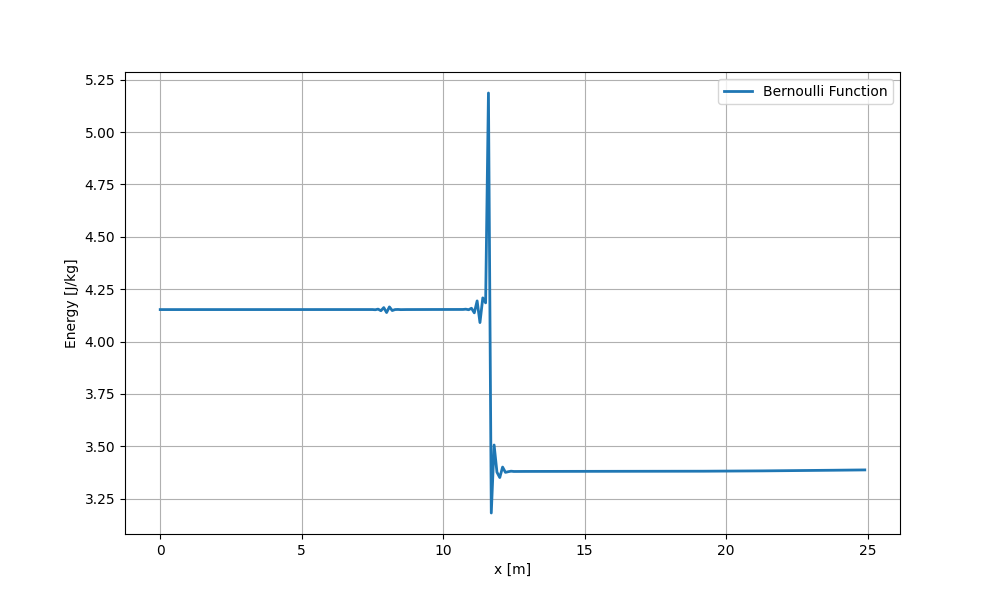

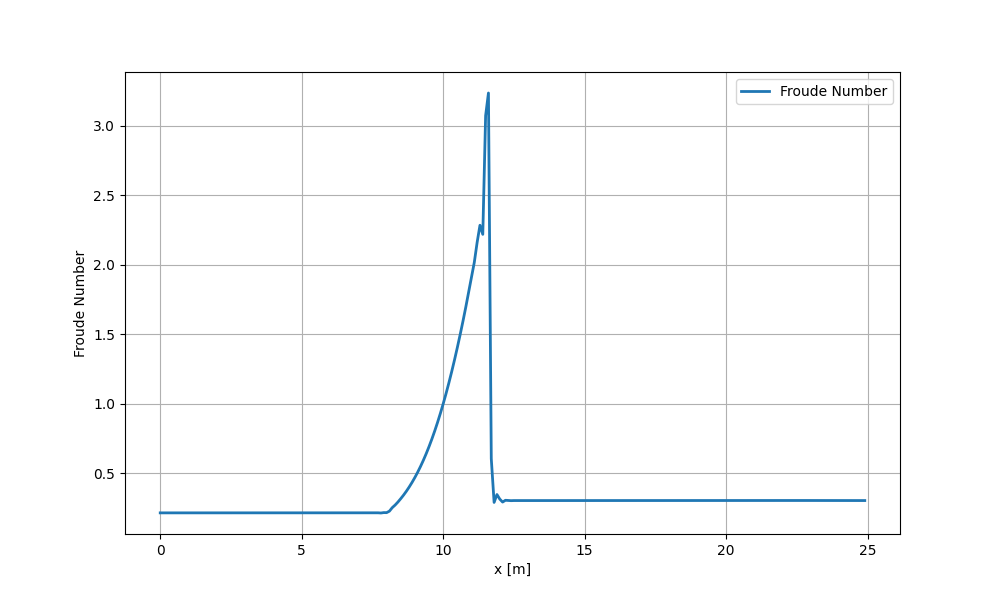

In [ ]:
# Plot the Bernoulli function (energy) and Froude number of the steady state solution.

h = ds.A.sel(time=ds.time.values[-2]) / ds.b
zb = ds.zb
u = ds.Q.sel(time=ds.time.values[-2]) / ds.A.sel(time=ds.time.values[-2])

B = 0.5 * u**2 + 9.81 * (zb + h)
Fr = np.sqrt(u**2 / (9.81 * h))

plt.figure(figsize=(10, 6))
plt.plot(ds.x, B, linewidth=2, label='Bernoulli Function')
plt.xlabel('x [m]')
plt.ylabel('Energy [J/kg]')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(ds.x, Fr, linewidth=2, label='Froude Number')
plt.xlabel('x [m]')
plt.ylabel('Froude Number')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Generate a set of downstream Bernoulli function values

B_up = B.sel(x=10, method='nearest').values
h_reservoir = np.arange(0.15, 0.45, 0.01)
zb = ds.zb.values
B_down_set = 0.5 * (Qup**2) / h_reservoir**2 + 9.81 * (zb[-1] + h_reservoir)
g = 9.81
Mguess = (Qup**2) / (g * 0.1) + 0.5 * g * 0.1**2

[2.1915     2.2024125  2.22825363 2.2658     2.31265346 2.367
 2.42744694 2.49291074 2.56253819 2.63565    2.7117     2.79024497
 2.87092222 2.95343265 3.03752782 3.123      3.2096744  3.29740313
 3.38606033 3.47553841 3.5657449  3.6566     3.74803455 3.83998837
 3.93240888 4.02525    4.11847121 4.21203673 4.30591493 4.40007769
 4.4945    ]


In [ ]:
# Find the position where momentum flux is conserved

from scipy.optimize import minimize_scalar, root_scalar

def jump(d, zb, B):
    res = (B - 0.5 * (Qup / d)**2 - g * (zb + d))**2
    return res

# since the up stream energy is fixed, we calculate it once and for all.
d_up_root = np.array([minimize_scalar(jump, bounds=(0, 0.15), args=(zi, B_up), method='bounded') for zi in ds.zb.values])
M = lambda d: (Qup**2) / d + 0.5 * g * d**2
M_up = M(np.array([res.x for res in d_up_root]))

x_jump = []
jump_range = np.where(ds.x > 10)[0]

for B_down, h_res in zip(B_down_set, h_reservoir):
    d_down_root = np.array([minimize_scalar(jump, bounds=(0, 1), args=(zi, B_down), method='bounded') for zi in ds.zb.values])
    success_mask = np.array([res.success for res in d_down_root])
    if success_mask.sum() < 250:
        print(f'h_reservoir = {h_res:.2f}m failed')
        # continue
    M_down = M(np.array([res.x for res in d_down_root]))
    plt.figure(figsize=(10, 6))
    plt.plot(ds.x[success_mask], M_up[success_mask], label='Upstream Momentum Flux')
    plt.plot(ds.x[success_mask], M_down[success_mask], label='Downstream Momentum Flux')
    plt.xlabel('x [m]')
    plt.ylabel('Momentum Flux [m^3/s^2]')
    plt.legend()
    plt.grid()
    plt.ylim(-0.5, 1.5)
    plt.savefig(f'demo/momentum_flux_Bdown_{B_down:.2f}_hres_{h_res:.2f}.png')
    plt.close()
    
    # find where the momentum fluxes cross (jump location)
    M_diff = M_up[jump_range] - M_down[jump_range]
    x_sub = ds.x.values[jump_range]

    # detect sign change (crossing of M_diff = 0)
    s = np.sign(M_diff)
    cross_idx = np.where(np.diff(s) != 0)[0]

    if M_diff.min() > 0:
        x_jump.append(np.argmin(np.abs(ds.x.values - x_sub[-1])))
    elif M_diff.max() < 0:
        x_jump.append(np.argmin(np.abs(ds.x.values - x_sub[0])))
    elif cross_idx.size > 0:
        i0 = cross_idx[0]  # first crossing downstream of x=10
        x0, x1 = x_sub[i0], x_sub[i0 + 1]
        y0, y1 = M_diff[i0], M_diff[i0 + 1]

        # linear interpolation for zero crossing location
        x0_cross = x0 - y0 * (x1 - x0) / (y1 - y0)
        x_jump.append(np.argmin(np.abs(ds.x.values - x0_cross)))

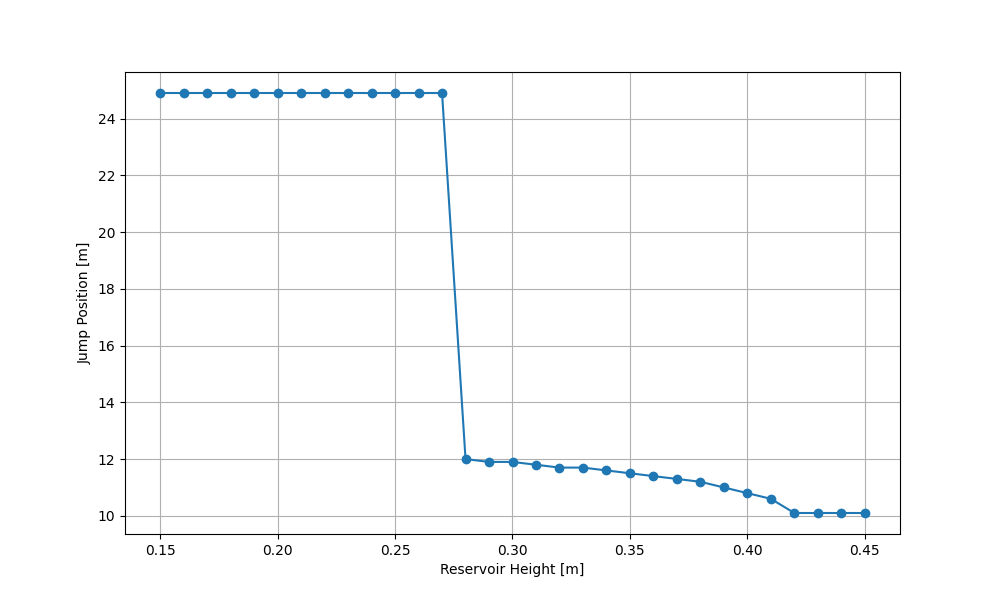

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(h_reservoir, ds.x[x_jump], marker='o')
plt.xlabel('Reservoir Height [m]')
plt.ylabel('Jump Position [m]')
plt.grid()
plt.show()

See that the Hydraulic jump position is suddenly changed when the Reservoir height is lifted to around 0.28m, which is the right foot of the bump, and then it slowly climbs up the bump as the reservoir height increases. We've demonstrated this phenomenon in the lab.

# 4 Conclusion

While measuring flow rates we were able to predict the behvaiour over two types of weirs to a reasonable degree. Due to the imprescise nature of fluid mechanics this constant we predicted to be one is often not actually the case from friction effects. The data likely can be improved by taking more flow rate points and measuring that flow rate more precisely. Next we used this data to perdict the time it would take to inital spill over each weir. The issue with these measuremnts is that the friction effects are acounted for with general constants not exact constants of the materials used in the system.

While controlling the downstream water level, one important thing we need to consider is the position of the hydraulic jump, as it dissipates a lot of energy. In the simulation, we assumed no friction, which causes the sudden changes of the jump position. In reality, when the friction is considered, the shift of the jump in the downstream region will be more gradual, but still sudden comparing to the 'climbing up' section.